In [39]:
# ========================
# q-voter - modified model
# ========================
# 1) Agent Based Modeling and Monte Carlo type of simulation
# 2) q-voter implemented
# 3) based on Watts-Strogatz graph
# 4) exploring how customers churn in face of (un)successful ads, which are sent episodically throughout the simulation
# 5) not every ad reaches every agent in the simulation
# 6) each agent has the same amount of neighbors, as it is watts-strogatz model (BASE - further we explore different Beta values)
# 7) if q neighbors have different opinions, the agent proceeds to flip whether to churn or not
# 8) if agent has been exposed to ad that is successful, it is harder for him to successfully flip for churn
# 9) if agent hasn't been exposed to ad, his flipping threshold is based on agents own baseline senstivity (each agent has different)

In [40]:
import numpy as np
import random
import time
import matplotlib.pyplot as plt
import networkx as nx
from numba import njit, prange

@njit
def mod_qvoter(neighbors_matrix, degree_array, states, q, p_std, p_inc, steps):
    
    # neighbors_matrix = 2d numpy array, where each row is an agent and the columns
    # are the IDs of their neighbors

    # degree_array = array with how many neighbors each agent has

    # states = array storing actual customer states (1 for loyay, 0 means churned)

    # ad_affinity = array storing each agent's baseline sensitivityg to ads

    # q = q neighbors in simulation
    # p_std = flip chance (standard)
    # p_inc = flip chance (boosted)
    # steps = monte carlo steps

    N = len(states) # number of agents N is determined by length of states array
    churn_rates = np.empty(steps) # reserving space in array for churn values

    ad_interval = max(1, steps // 10) # ads are sent into the simulation every 10% of the steps
    ad_impacted = np.zeros(N, dtype=np.bool_) # tracking which agent is under influence of an ad

    for step in range(steps):
        # Monte Carlo step = N random individual updates
        
        # https://journals.sagepub.com/doi/10.1016/j.intmar.2011.12.001
        # above is the paper showing, that average success rate of online ad campaigns among
        # already established customer base is between 5-20%

        if step % ad_interval == 0:
            # generating random success impact between 5% and 20% based on literature
            impact_rate = 0.05 + np.random.rand() * 0.15
            for i in range(N): # which agents will be impacted by specific ad campaign
                ad_impacted[i] = (np.random.rand() < impact_rate)
        
        else:
            for i in range(N): # the ad wears off and nobody is impacted (when ads are not sent)
                ad_impacted[i] = False
        
        for _ in range(N):
            node = np.random.randint(0, N)
            deg = degree_array[node]
            if deg == 0:
                continue

            if ad_impacted[node]: # flip probability determination
                if states[node] == 1: # if agenst saw the ad and liked it
                    current_p = p_std[node] / 2.0 # making it harder to churn
                else: 
                    current_p = p_inc # making it easier to return if client already churned
            
            else:
                current_p = p_std[node] # if agent hasn't seen our ads

            # select q random neighbors
            if deg <= q:
                # if the degree is less or equal to q -> take all neighbors
                all_same = True
                first_state = states[neighbors_matrix[node, 0]]
                for i in range(1, deg):
                    if states[neighbors_matrix[node, i]] != first_state:
                        all_same = False
                        break
                        
                if all_same:
                    states[node] = first_state
                else:
                    if np.random.rand() < current_p:
                        states[node] = 1 - states[node]
            else:
                # picking q distinct neighbors from the graph
                sampled = np.empty(q, dtype=np.int64)
                count = 0
                while count < q:
                    idx = np.random.randint(0, deg)
                    val = neighbors_matrix[node, idx]
                    
                    already_picked = False
                    for i in range(count):
                        if sampled[i] == val:
                            already_picked = True
                            break
                            
                    if not already_picked:
                        sampled[count] = val
                        count += 1
                        
                all_same = True
                first_state = states[sampled[0]]
                for i in range(1, q):
                    if states[sampled[i]] != first_state:
                        all_same = False
                        break
                        
                if all_same:
                    states[node] = first_state
                else:
                    if np.random.rand() < current_p:
                        states[node] = 1 - states[node]
                        
        # overall churn rate for a single step
        churns = 0
        for i in range(N):
            if states[i] == 0:
                churns += 1
        churn_rates[step] = churns / N
        
    return churn_rates

In [41]:
# The following is the idea of claude - for visualization purposes it proposed
# making parallel Monte Carlo Simulations by using @njit(parallel=True)
# and establishing confidence interval based on said simulations for every
# beta value. That's actually quite a brilliant idea.

@njit(parallel=True)
def parallel_mc_runs(neighbors_matrix, degree_array, q, p_inc, steps, num_simulations, N, initial_churn):
    # storing results in a 2d array
    all_churn_rates = np.empty((num_simulations, steps), dtype=np.float64)
   
    for sim in prange(num_simulations):
        states = np.empty(N, dtype=np.int64) # random initial states
        for i in range(N):
            states[i] = 1 if np.random.rand() > initial_churn else 0
            
        p_std = np.random.uniform(0.05, 0.15, N) # random sensitiveness
        all_churn_rates[sim, :] = mod_qvoter(neighbors_matrix, degree_array, states, q, p_std, p_inc, steps)
        
    return all_churn_rates

In [42]:
def nx_to_numba_arrays(G):

    # transforming networx graph into 2d matrix format for Numba to be 
    # available to work (it can't work on networkx graphs)

    N = G.number_of_nodes()
    max_deg = max([d for n, d in G.degree()])
    
    # array with -1s
    neighbors_matrix = np.full((N, max_deg), -1, dtype=np.int64)
    degree_array = np.zeros(N, dtype=np.int64)
    
    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        deg = len(neighbors)
        degree_array[node] = deg
        for i in range(deg):
            neighbors_matrix[node, i] = neighbors[i]
            
    return neighbors_matrix, degree_array

In [43]:
# simulation parameters
betas = [0.0, 0.05, 0.2, 0.35, 0.5, 1.0] # <-- beta parameter for watts-strogatz
                              # beta 0 meaning every agent has the same amount
                              # of neighbors. The rewiring does not occur
N = 50000 # <-- number of nodes
k = 8 # <-- k nearest neighbors for Watts-Strogatz graph
q = 4 # <-- q neighbours in q-voter model
p_inc = 0.4 # <-- boosted flipping probabilty for churned customers seeing an ad
steps = 300 # <-- how many Monte Carlo simulation steps
initial_churn = 0.3 # <-- initial churn value (TO BE BACKED UP BY LITERATURE)
num_simulations = 100 # <-- how many Monte Carlo simulations should be run for each beta (for the 1st visualization)

In [44]:
# FIRST VISUALIZATION - CHURN RATE FOR DIFFERENT BETA VALUES

def churn_for_betas():
    
    plt.figure(figsize=(10, 6))
    for beta in betas:
        start_time = time.time()
        
        # 1. Build the W-S graph
        G = nx.watts_strogatz_graph(N, k, beta)
        neighbors_matrix, degree_array = nx_to_numba_arrays(G) 
        
        # 2. Run the parallelized Monte Carlo simulations
        all_churn_rates = parallel_mc_runs(
            neighbors_matrix, degree_array, q, p_inc, steps, num_simulations, N, initial_churn
        )
        
        # 3. Calculate Mean and Empirical 95% Confidence Intervals
        mean_churn = np.mean(all_churn_rates, axis=0)
        ci_lower = np.percentile(all_churn_rates, 2.5, axis=0) # Bottom 2.5%
        ci_upper = np.percentile(all_churn_rates, 97.5, axis=0) # Top 97.5%
        
        comp_time = time.time() - start_time
        print(f"Beta {beta} computation time ({num_simulations} runs): {comp_time:.4f}s")
        
        # 4. Plot Mean line and shaded Confidence Interval
        p = plt.plot(mean_churn, label=f'$\\beta={beta}$', linewidth=2)
        color = p[0].get_color() # Grab the line color so the shading matches
        plt.fill_between(range(steps), ci_lower, ci_upper, color=color, alpha=0.2)
        
    plt.title(f'Customer churn for different Beta values\n(Mean & 95% CI over {num_simulations} MC simulations)', fontsize=14)
    plt.xlabel('MC simulation steps', fontsize=12)
    plt.ylabel('Churn rate', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [45]:
# SECOND VISUALIZATION - CONCENTRATION OF LOYAL CUSTOMERS OVER DIFFERENT BETA VALUES

def loyal_clients_concentration():
    initial_loyal_fractions = np.linspace(0, 1.0, 11)
    for beta in betas:

        plt.figure(figsize=(8, 6))
        start_time = time.time()
        
        # building W-S graph
        G = nx.watts_strogatz_graph(N, k, beta)
        neighbors_matrix, degree_array = nx_to_numba_arrays(G)
        
        # looping over concentrations
        for c0 in initial_loyal_fractions:
            states = np.array([1 if random.random() < c0 else 0 for _ in range(N)], dtype=np.int64)
            p_std = np.random.uniform(0.05, 0.15, N).astype(np.float64) 

            churn_rates = mod_qvoter(neighbors_matrix, degree_array, states, q, p_std, p_inc, steps)
            loyal_rates = 1.0 - churn_rates
            
            plt.plot(range(steps), loyal_rates, 'ro--', markersize=5, markevery=200, linewidth=2)

        comp_time = time.time() - start_time
        print(f"Beta {beta} computation time: {comp_time:.4f}s")
        
        plt.title(f'Concentration of Loyal Clients ($\\beta={beta}$)', fontsize=16)
        plt.xlabel('MCS', fontsize=16)
        plt.ylabel('Concentration', fontsize=16)
        plt.xlim(0, steps)
        plt.ylim(0, 1.0)
        plt.tight_layout()
        plt.show()

Beta 0.0 computation time (100 runs): 47.1789s
Beta 0.05 computation time (100 runs): 50.1121s
Beta 0.2 computation time (100 runs): 52.5880s
Beta 0.35 computation time (100 runs): 53.4092s
Beta 0.5 computation time (100 runs): 57.2421s
Beta 1.0 computation time (100 runs): 55.6798s


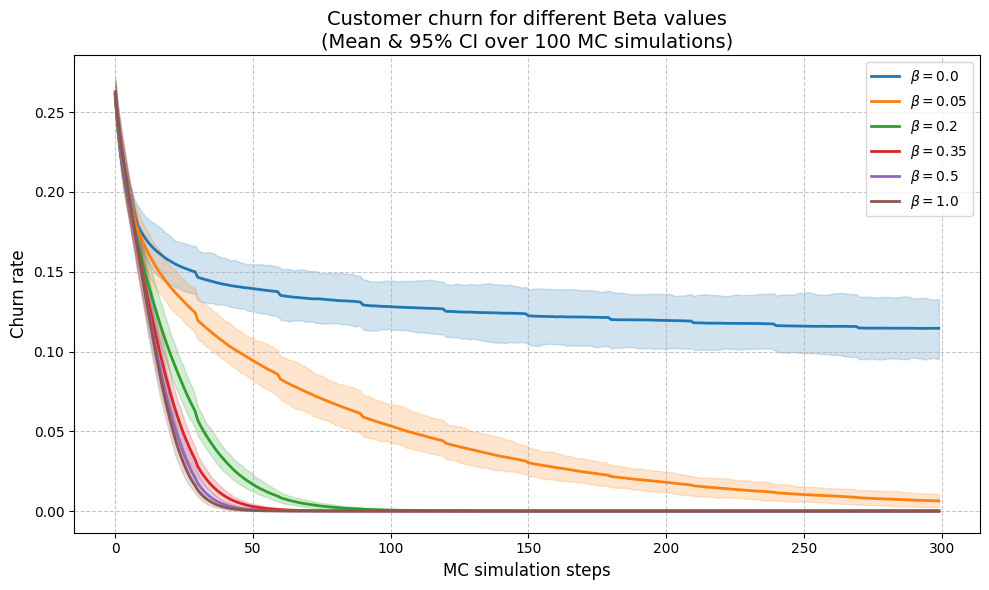

In [46]:
churn_for_betas()

Beta 0.0 computation time: 43.6782s


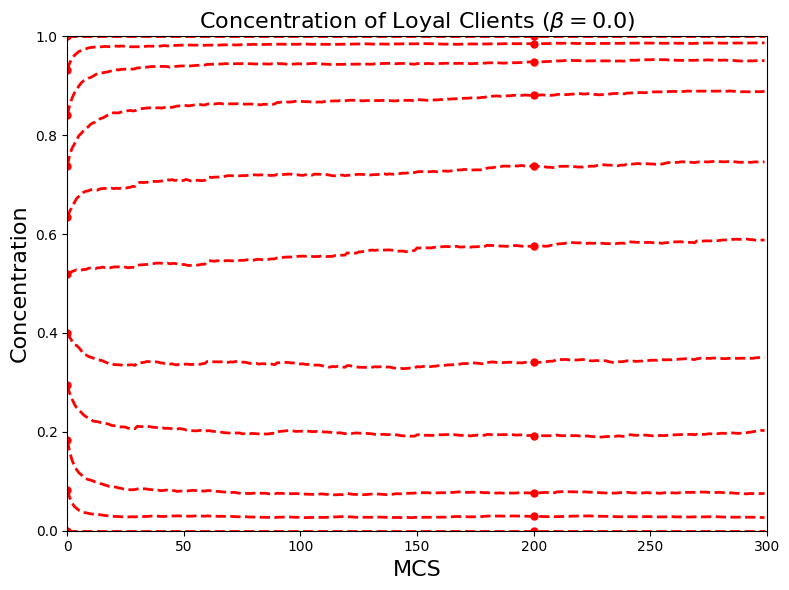

Beta 0.05 computation time: 50.1741s


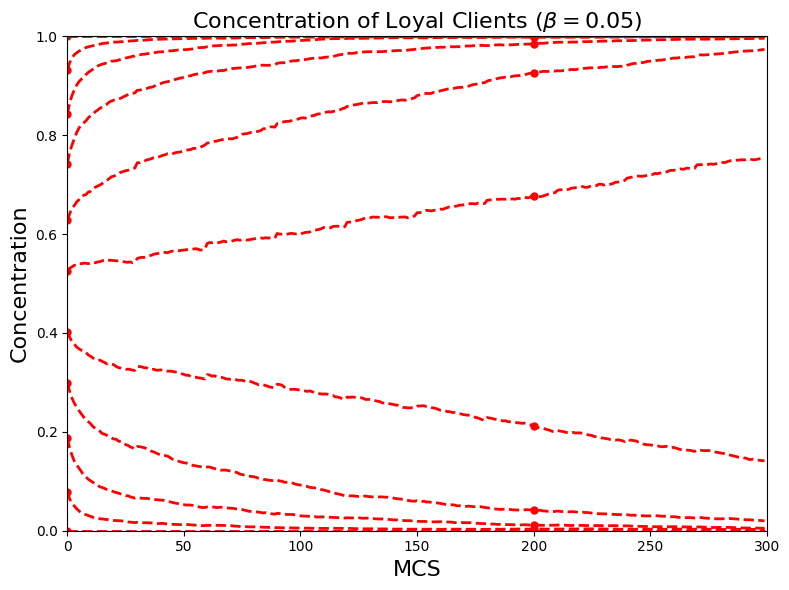

Beta 0.2 computation time: 56.2490s


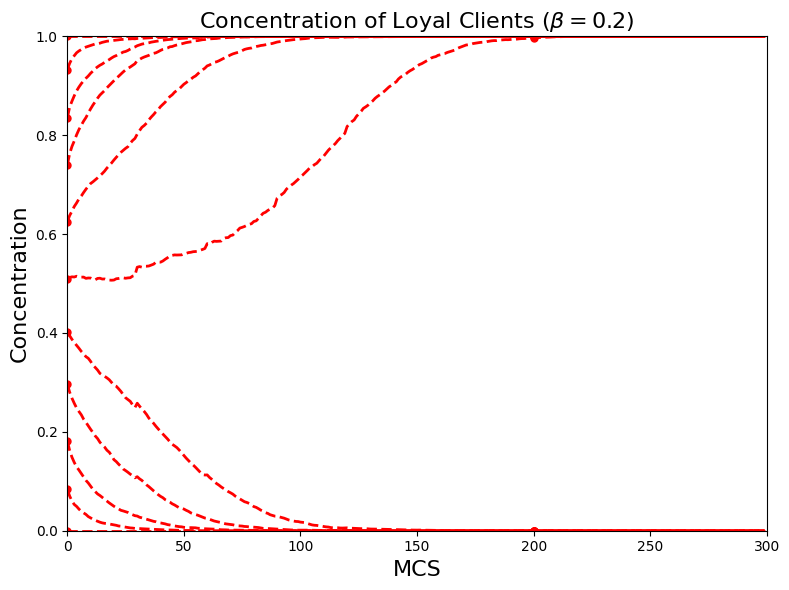

Beta 0.35 computation time: 57.6505s


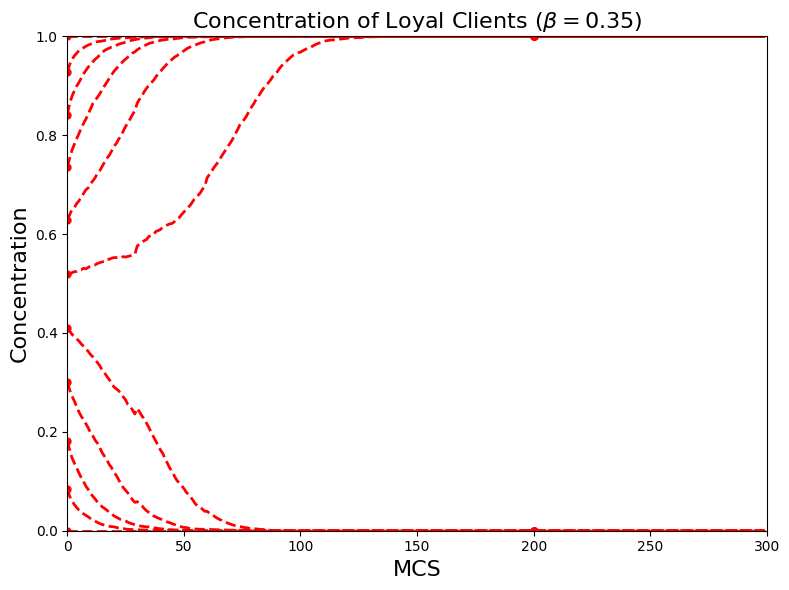

Beta 0.5 computation time: 59.5977s


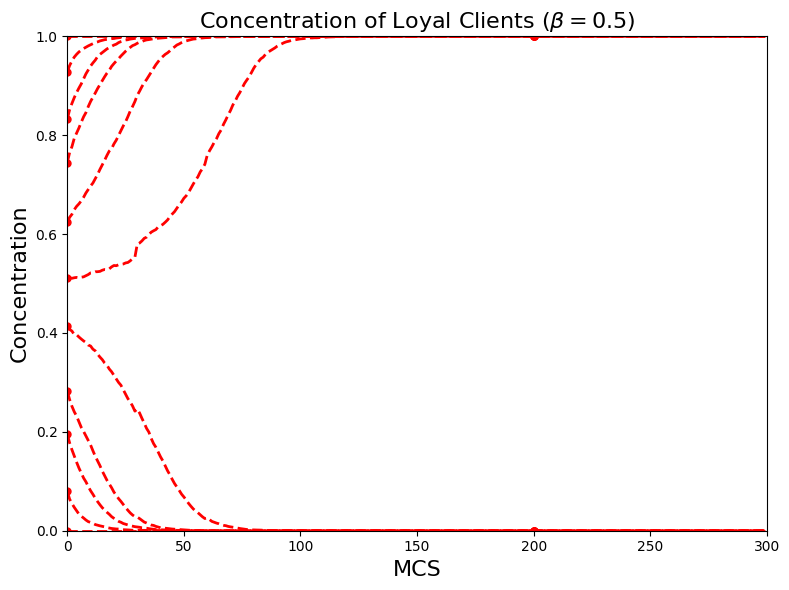

Beta 1.0 computation time: 59.0296s


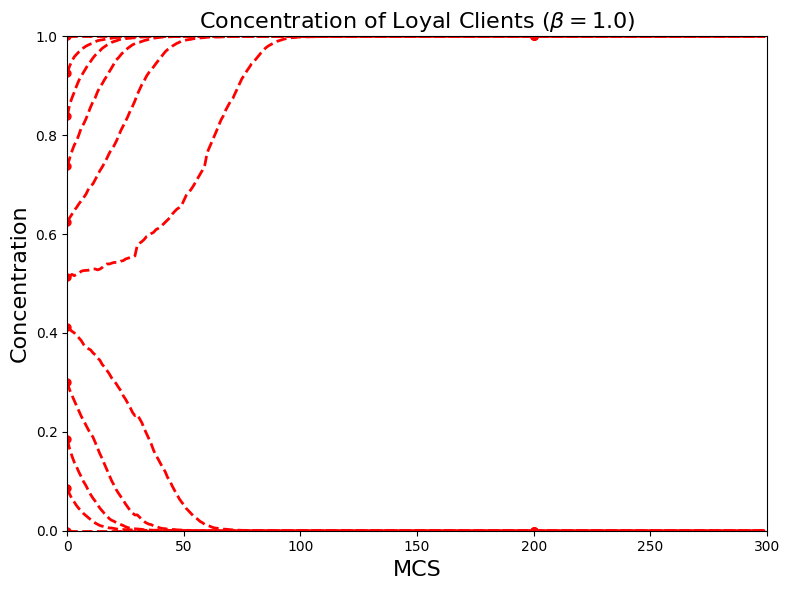

In [47]:
loyal_clients_concentration()